# Storytelling Application using Hugging Face Pipelines
**ISOM5240 Assignment** — Image → Caption → Story → Audio  
Application for 3–10 year-old kids

In [11]:
!git clone https://github.com/wshuaiaa/ISOM-5420-Assignment.git
%cd ISOM-5420-Assignment

Cloning into 'ISOM-5420-Assignment'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 7 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 55.48 KiB | 6.16 MiB/s, done.
/content/ISOM-5420-Assignment/ISOM-5420-Assignment


In [10]:
!pip install "transformers<5.0.0" torch pillow

In [2]:
# Storytelling Application using Hugging Face Pipelines (Notebook version)
# Imports
import numpy as np
from transformers import pipeline
from PIL import Image
from IPython.display import display, Audio

In [3]:
# --- Function definitions ---
# Stage 1: Image to Text (caption) - recommended model per assignment
def img2text(image_path):
    """Generate a descriptive caption from the uploaded image using BLIP."""
    pipe = pipeline("image-to-text", model="Salesforce/blip-image-captioning-base")
    result = pipe(image_path)[0]["generated_text"]
    return result

# Stage 2: Text to Story - transform caption into a short narrative (max 100 words)
def text2story(prompt_text, max_words=100):
    """Generate a narrative of no more than 100 words for the story."""
    pipe = pipeline("text-generation", model="pranavpsv/genre-story-generator-v2")
    out = pipe(prompt_text, max_new_tokens=150)[0]["generated_text"]
    words = out.split()
    if len(words) > max_words:
        out = " ".join(words[:max_words])
    return out

# Stage 3: Text to Audio - convert story to speech for playback
def text2audio(text):
    """Convert the generated story into audio format (returns dict with 'audio', 'sampling_rate')."""
    pipe = pipeline("text-to-speech", model="Matthijs/mms-tts-eng")
    return pipe(text)

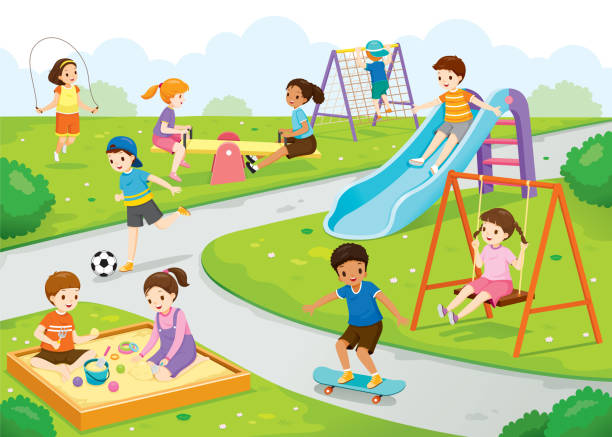

Stage 1: Image to Text (caption)...


model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Device set to use cpu


Caption: children playing in the park illustration

Stage 2: Generating story...


config.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/248 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/145M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

Device set to use cpu


In [9]:
# --- Main: Image filename in current working directory ---


# Set the image filename (file must be in the current working directory)
image_filename = "test_kids_playing.jpg"   # Change this to your image filename

# Load and display the uploaded image
img = Image.open(image_filename).convert("RGB")
display(img)

# Stage 1: Image to Text (caption)
print("Stage 1: Image to Text (caption)...")
scenario = img2text(image_filename)
print("Caption:", scenario)

# Stage 2: Text to Story (narrative, no more than 100 words)
print("\nStage 2: Generating story...")
story = text2story(scenario)
print("Story:", story)
print(f"\nWord count: {len(story.split())}")

# Stage 3: Text to Audio
print("\nStage 3: Converting story to audio...")
audio_data = text2audio(story)

# Play audio in notebook (for 3–10 year-old kids)
audio_array = np.array(audio_data["audio"]).squeeze()
sample_rate = audio_data["sampling_rate"]
display(Audio(audio_array, rate=sample_rate))